# PyTorch for Neural Networks

### by Mingfei Sun

In this Notebook, we look at the torch library in Python that allows automatic differentiation. PyTorch will be used to implement different neural network models later on.

### Tensors
A tensor generalises the concept of vectors and matrices to an arbitrary number of dimensions. Another name for the same concept is multidimensional arrays. The dimensionality of a tensor is the number of indexes used to refer to scalar values within the tensor. The cell below shows an example initialising a Tensor uniformly for 1D, 2D and 3D:

In [38]:
# We first import the torch library that comes with the Anaconda distribution
import torch
# Tensor 1D presents 1 index
y = torch.rand([2])
print('Tensor 1D presents one index','with shape', y.shape,':\n',y) #get specific size with .shape
# Tensor 2D presents 2 indexes
y = torch.rand([2,3])
print('\nTensor 2D presents two indexes','with shape',y.shape,':\n',y)
#Tensor 3D presents 3 indexes
y = torch.rand([5,2,3])
print('\nTensor 3D presents three indexes','with shape',y.shape,':\n',y)

Tensor 1D presents one index with shape torch.Size([2]) :
 tensor([0.7787, 0.6090])

Tensor 2D presents two indexes with shape torch.Size([2, 3]) :
 tensor([[0.5462, 0.3385, 0.5823],
        [0.9230, 0.2117, 0.2837]])

Tensor 3D presents three indexes with shape torch.Size([5, 2, 3]) :
 tensor([[[0.9280, 0.6397, 0.2486],
         [0.0900, 0.1759, 0.7513]],

        [[0.9510, 0.8284, 0.4976],
         [0.3317, 0.6440, 0.2479]],

        [[0.5420, 0.8459, 0.3642],
         [0.8226, 0.4018, 0.8698]],

        [[0.6301, 0.8546, 0.7955],
         [0.7532, 0.2167, 0.6567]],

        [[0.3882, 0.6691, 0.6030],
         [0.3674, 0.4555, 0.1460]]])


In [39]:
# Create a tensor with specific values
x = torch.tensor([4.0,5.0],dtype=torch.float32)
y = torch.tensor([2.0,3.0],dtype=torch.float32)

# Tensor multiplication (point-wise multiplication)
print(x*y)

tensor([ 8., 15.])


### Initialise a tensor with torch.zeros or torch.ones

In [40]:
x_zeros = torch.zeros([3,4])
print('x_zeros:',x_zeros,'with shape',x_zeros.shape,'\n')
x_ones = torch.ones([2,6])
print('x_ones:',x_ones,'with shape',x_ones.shape)

x_zeros: tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]) with shape torch.Size([3, 4]) 

x_ones: tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]]) with shape torch.Size([2, 6])


### Reshape a tensor using .view

In [41]:
y = torch.ones([3,2])
y_reshaped = y.view(6,1)  # in contrast to the common numpy library, we use .view instead of .reshape
print(y_reshaped)

tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


### Numpy interoperability

PyTorch tensors can be converted efficiently to NumPy arrays and vice versa. By doing so, you can leverage the huge swath of functionality in the wider Python ecosystem that has built up around the NumPy array type.

In [42]:
# Tensor_torch to tensor Numpy
Tensor_torch = torch.ones(3,4)
Tensor_numpy = Tensor_torch.numpy() #Returns a NumPy multidim. array of the right size, shape and numerical type.
print('Array in numpy form with shape', Tensor_numpy.shape,':\n',Tensor_numpy)

# Tensor Numpy to Tensor_torch
import numpy as np
Tensor_np = np.random.randn(5,8)
Tensor_numpy_to_torch = torch.from_numpy(Tensor_np)
print('\nArray from Numpy to Torch with shape', Tensor_numpy_to_torch.shape,':\n',Tensor_numpy_to_torch)

Array in numpy form with shape (3, 4) :
 [[1. 1. 1. 1.]
 [1. 1. 1. 1.]
 [1. 1. 1. 1.]]

Array from Numpy to Torch with shape torch.Size([5, 8]) :
 tensor([[ 0.9829,  0.3977,  0.2337, -0.9000,  2.4305, -1.7618, -0.9218, -0.5735],
        [-0.2695, -0.5976, -0.5828,  0.4007, -1.7462, -0.4602, -0.2831,  1.4982],
        [ 1.9383,  0.8949, -1.8129, -0.4535,  0.9713,  0.0459,  0.1488, -0.8580],
        [ 2.5494, -1.2818,  0.9461, -1.5521,  0.8346, -0.0149, -0.8809, -0.6844],
        [-0.0850, -0.0428,  0.1937, -0.2293, -0.2975, -0.6449, -0.5982, -0.5703]],
       dtype=torch.float64)


## Automatic Differentiation

PyTorch allows to automatically obtain the gradients of a tensor with respect to a defined function. When creating the tensor, we have to indicate that it requires the gradient computation using the flag `requires_grad`  

In [43]:
x = torch.rand(3,requires_grad=True)
print(x)

tensor([0.6676, 0.7006, 0.3609], requires_grad=True)


Notice that now the Tensor shows the flag `requires_grad` as True. We can also activate such a flag in a Tensor already created as follows:

In [44]:
x = torch.tensor([1.0,2.0,3.0])
print(x)
x.requires_grad_(True)
print(x)

tensor([1., 2., 3.])
tensor([1., 2., 3.], requires_grad=True)


Let us define a function $y=x^2+5$. The function $y$ will not only carry the result of evaluating $x$, but also the gradient function $\frac{\partial y}{\partial x}$ called `grad_fn` in the new tensor $y$

In [45]:
x = torch.tensor([2.0])
x.requires_grad_(True)  # indicate we will need the gradients with respecto to this variable
y = x**2 + 5
print(y)

tensor([9.], grad_fn=<AddBackward0>)


To evaluate the partial derivative $\frac{\partial y}{\partial x}$, we use the `.backward()` function and the result of the gradient evaluation is stored in `x.grad`

In [46]:
y.backward()  #dy/dx
print('PyTorch gradient:', x.grad)

# Let us compare with the analytical gradient of y = x**2+5
with torch.no_grad():    # this is to only use the tensor value without its gradient information
    dy_dx = 2*x  # analytical gradient
print('Analytical gradient:', dy_dx)

PyTorch gradient: tensor([4.])
Analytical gradient: tensor([4.])


If we evaluate a vector $\mathbf{w}=[w_1, \ldots, w_D]^{\top}$, to compute another vector $\mathbf{g}=[g_1, \ldots, g_D]^{\top}$ with elements $g_i=w_i^2+5$, then we obtain a vector $\mathbf{g}$ that contains each evaluation of the function. If we want to obtain the gradient w.r.t $\mathbf{w}$ by using "g.backward()", we have to bypass a vector of size equal to w.shape to the function, i.e., "g.backward(vect)".

In [47]:
w = torch.tensor([1.0,2.0,3.0])
w.requires_grad_(True)

g = w**2+5
# Below, the values [1.0,1.0,1.0] are multiplied by the gradient g.backward(vect)
# of course using the ones does not modify the value of the gradient
vect = torch.tensor([1.0,1.0,1.0],dtype=torch.float32)
g.backward(vect)
print(w.grad)

tensor([2., 4., 6.])


On the other hand, when accessing the gradients in a for loop, PyTorch acummulates the gradients at each
iteration. In order to avoid this behaviour, we have to use the function .grad.zero_() also at each iteration. See in the example below what happens when commenting and uncommenting the line "w.grad.zero_()":

In [48]:
#Pytorch uses a cumulative process for the gradients
w = torch.tensor([1.0,2.0,3.0])
w.requires_grad_(True)

for i in range(3):
    g = w**2+5
    g.backward(torch.ones_like(w))
    print(w.grad)
    w.grad.zero_()    #this line avoids the acummulation of the gradients uncomment it to see its effect

tensor([2., 4., 6.])
tensor([2., 4., 6.])
tensor([2., 4., 6.])


###  Question 1

Verify that the gradients provided by PyTorch coincide with the analytical gradients of the function $f = \exp \big(-x^2-2x- \sin (x) \big)$ w.r.t $x$.

In [49]:
# Provide your answer here
import torch

x = torch.tensor([1.0], requires_grad = True)
f = torch.exp(-x**2-2*x-torch.sin(x))
f.backward()
print(x.grad.item())

analytical_grad = torch.exp(-x**2-2*x-torch.sin(x))*(-2*x-torch.cos(x)-2)
print(analytical_grad.item())

-0.09744400531053543
-0.09744400531053543


## Linear Regression Basic Example

We now provide a very simple example of linear regression with one input dimension, $y=wx+b$, and illustrate how we use PyTorch to optimise the parameters of the model

In [50]:
Ndata = 100
x = torch.rand(Ndata)
true_w = 1.5
true_bias = 1.0
# We generate the dataset from the actual model but adding some noise
y = true_w*x + true_bias + 0.05*torch.randn(Ndata)
# We make sure to set the requires_grad flag to True for both paratemers
w = torch.tensor(0.0,dtype=torch.float32,requires_grad=True)
bias = torch.tensor(0.0,dtype=torch.float32,requires_grad=True)

We now define two useful functions, the prediction function and the objective function

In [51]:
def model_prediction(x,w,bias):
    return w*x + bias

def loss_function(y,y_pred):
    return ((y_pred-y)**2).mean()  # Mean Squared Error (MSE)

And we use gradient descent to estimate the parameters of the model

\begin{align*}
    w_{k+1} = w_k - \eta \frac{dE}{dw}\\
    b_{k+1} = b_k - \eta \frac{dE}{db}\\
\end{align*}

We know that there is a closed form solution for $w$ and $b$ through the normal equation. The example is for illustrative purposes.

In [52]:
Max_Niter = 500
step_size = 0.1
for Niter in range(Max_Niter):
    # Evaluate the prediction and the loss
    y_approx = model_prediction(x,w,bias)
    my_loss = loss_function(y,y_approx)

    # The function .backward() has to be called in order to load the grads in w.grad
    # Notice that here it is not necessary to bypass a vector since loss_function is a scalar function
    my_loss.backward()

    with torch.no_grad():        # this line avoids the gradient update while allowing to change the value of w
        w -= step_size * w.grad    # it is necessary to avoid the grad update while modifying the variable
        bias -= step_size * bias.grad

    # Make the zero gradient to avoid acummulation
    w.grad.zero_()
    bias.grad.zero_()

    # We print the loss, and the parameters values every 50 iterations
    if Niter%50==0:
        print(f'Iteration = {Niter+1}, Loss = {my_loss:.8f}, w = {w:.3f}, bias = {bias:.3f}')

print(f'Iteration = {Niter+1}, Loss = {my_loss:.8f}, w = {w:.3f}, bias = {bias:.3f}')

Iteration = 1, Loss = 3.25410342, w = 0.201, bias = 0.349
Iteration = 51, Loss = 0.01483789, w = 1.140, bias = 1.191
Iteration = 101, Loss = 0.00538465, w = 1.326, bias = 1.091
Iteration = 151, Loss = 0.00309882, w = 1.417, bias = 1.042
Iteration = 201, Loss = 0.00254610, w = 1.462, bias = 1.018
Iteration = 251, Loss = 0.00241245, w = 1.484, bias = 1.006
Iteration = 301, Loss = 0.00238013, w = 1.495, bias = 1.000
Iteration = 351, Loss = 0.00237231, w = 1.500, bias = 0.997
Iteration = 401, Loss = 0.00237042, w = 1.503, bias = 0.996
Iteration = 451, Loss = 0.00236997, w = 1.504, bias = 0.995
Iteration = 500, Loss = 0.00236986, w = 1.505, bias = 0.995


We finally plot the result

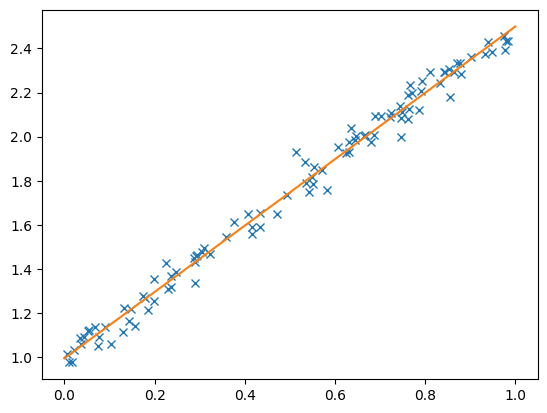

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(x,y,'x')
xtest = torch.linspace(0,1,10)
with torch.no_grad():
    y_pred = model_prediction(xtest,w,bias)
plt.plot(xtest,y_pred)

### Loading a .csv dataset

We can take advantage of the interoperability between Numpy and PyTorch by loading a .csv data as a numpy array and transforming it to a Torch Tensor using `torch.from_numpy(dataset_np)`.

In [54]:
# This cell is simply to download the winequality-red.csv dataset from its root url
import urllib.request
urllib.request.urlretrieve('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', './winequality-red.csv')

('./winequality-red.csv', <http.client.HTTPMessage at 0x7ba9f6548170>)

In [55]:
import numpy as np
#In the line below we avoid the first row (skiprows=1) of .csv file that contains names
#the delimeter of data for this dataset is ";"
wine_np = np.loadtxt("./winequality-red.csv",dtype=np.float32,delimiter=";",skiprows=1)
wine_torch = torch.from_numpy(wine_np)  #We take advantage of the interoperability with numpy
wine_torch

tensor([[ 7.4000,  0.7000,  0.0000,  ...,  0.5600,  9.4000,  5.0000],
        [ 7.8000,  0.8800,  0.0000,  ...,  0.6800,  9.8000,  5.0000],
        [ 7.8000,  0.7600,  0.0400,  ...,  0.6500,  9.8000,  5.0000],
        ...,
        [ 6.3000,  0.5100,  0.1300,  ...,  0.7500, 11.0000,  6.0000],
        [ 5.9000,  0.6450,  0.1200,  ...,  0.7100, 10.2000,  5.0000],
        [ 6.0000,  0.3100,  0.4700,  ...,  0.6600, 11.0000,  6.0000]])

# Pytorch for MLPs
We will now use the pytorch library to train the MLPs. We will use a dataset of digits (MNIST).

## Import libraries and load the dataset
If you are using your own computer, you will need to install Pytorch. Setup guidance is here: https://pytorch.org/get-started/locally/)

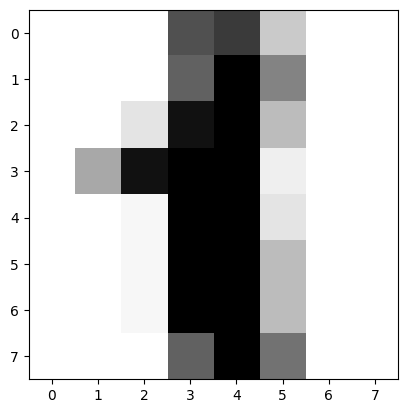

In [56]:
# import pytorch library (load the neural network module as nn, for convenience to save us writing torch.nn every time
import torch
import torch.nn as nn

# import the digits dataset
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
digits = datasets.load_digits()

# get one image
image1 = digits.images[1]
plt.imshow(image1, cmap='Greys')

As we discovered in the previous notebook, pytorch uses tensors as its base unit. So, we will first convert the digits dataset into tensors.

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn import preprocessing

X_scaled = preprocessing.scale(digits.data)

X_scaled_t = torch.from_numpy(X_scaled)
#X_scaled_t = torch.transpose(X_scaled_t,0,1)
y_t = torch.from_numpy(digits.target)

In the previous part, we explicitly wrote a function called *model_prediction* that described a linear regression model. We apply the same process here, but the model is a little more complex, so we use some of the inbuilt functions within Pytorch. The following code sets up a 1 hidden layer neural network with 20 neurons.

(You may have noticed that we have set up a class, rather than a function (def) here. Broadly, a class is an object that can have many functions applied to it. The nature of an Object is beyond the scope of this course, and if you are interested you should investigate material on object oriented programming).

In [58]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.input_size = input_size
        self.fc1 = torch.nn.Linear(input_size,20)
        self.fc2 = torch.nn.Linear(20,10)
        self.sigmoid = torch.nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.sigmoid(x)
        output = self.fc2(x)

        return output    # return output of network

Rather that explicitly writing out a loss function, we will use pytorch's inbuilt CrossEntropy loss.

In [59]:
loss_func = nn.CrossEntropyLoss()

We now create a training function - if you compare this to the previous part, you should see that it follows the same basic structure as the linear regression example.

The only exception is that we set the neural network into *train* mode using mlp.train. This is because some more advanced modifications to a neural network (e.g. batch normalisation) perform differently during training and running.

In [60]:
def train(num_epochs, network, X_train, y_train):

    # this sets the model mode - (i.e. layers like dropout, batchnorm etc behave differently during training compared to testing)
    # note that this function was not defined explicitly in CNN, but because CNN is a type of nn.Module, it inherits some functions
    # from the more general nn class.
    network.train()
    for epoch in range(num_epochs):
        output = network(X_train) # this is the model prediction
        loss = loss_func(output, y_train) # evaluate the loss (error)

        # clear gradients for this training step
        optimizer.zero_grad()

        # backpropagation, compute gradients
        loss.backward()
        # apply gradients
        optimizer.step()

        print ('Epoch [{}/{}], Loss: {:.4f}'.format(epoch + 1, num_epochs, loss.item()))

    # print the predicted (and true) labels after training. Note that raw output of the neural network is a score for each class, so we use argmax
    # to return the class with the highest score
    print(torch.argmax(output,1))
    print(y_train)

In [61]:
input_size = X_scaled_t.size(1) # input size is the same size as a digits image (8x8)
mlp = MLP(input_size) # set up an instance of the MLP object
mlp = mlp.double()

# use the adam optimiser to do the updates - this is a modern update to classic stochastic gradient descent
from torch import optim
optimizer = optim.Adam(mlp.parameters(), lr = 0.005)

# call the training function and run over 1000 epochs
num_epochs = 50
train(num_epochs, mlp, X_scaled_t, y_t.long())

Epoch [1/50], Loss: 2.3368
Epoch [2/50], Loss: 2.3003
Epoch [3/50], Loss: 2.2666
Epoch [4/50], Loss: 2.2351
Epoch [5/50], Loss: 2.2055
Epoch [6/50], Loss: 2.1773
Epoch [7/50], Loss: 2.1501
Epoch [8/50], Loss: 2.1236
Epoch [9/50], Loss: 2.0974
Epoch [10/50], Loss: 2.0714
Epoch [11/50], Loss: 2.0453
Epoch [12/50], Loss: 2.0192
Epoch [13/50], Loss: 1.9928
Epoch [14/50], Loss: 1.9663
Epoch [15/50], Loss: 1.9395
Epoch [16/50], Loss: 1.9126
Epoch [17/50], Loss: 1.8855
Epoch [18/50], Loss: 1.8582
Epoch [19/50], Loss: 1.8308
Epoch [20/50], Loss: 1.8033
Epoch [21/50], Loss: 1.7757
Epoch [22/50], Loss: 1.7481
Epoch [23/50], Loss: 1.7204
Epoch [24/50], Loss: 1.6928
Epoch [25/50], Loss: 1.6652
Epoch [26/50], Loss: 1.6377
Epoch [27/50], Loss: 1.6102
Epoch [28/50], Loss: 1.5829
Epoch [29/50], Loss: 1.5557
Epoch [30/50], Loss: 1.5286
Epoch [31/50], Loss: 1.5017
Epoch [32/50], Loss: 1.4749
Epoch [33/50], Loss: 1.4483
Epoch [34/50], Loss: 1.4220
Epoch [35/50], Loss: 1.3958
Epoch [36/50], Loss: 1.3698
E

## Questions
**Q1** Has the model finished training? (How can you tell whether it has or not?)

Yes, the model has finished training. We can tell this because the training loop ran for the specified number of epochs(50 epochs), and the output shows the loss for each epoch up to Epoch 50/50.

**Q2** Modify the *train* function above to dynamically set the number of training epochs, depending on the change in loss between iterations


**Q3** The size (number of neurons) of the hidden layer is 20. Try changing this - how does this affect the loss?

Increases: The model's expressive power enhances, which may fit the data more accurately, leading to a decrease in loss. However, if the number is too large, overfitting is likely to occur. In the later stage of training, the loss may no longer decrease significantly, and even increase on the test set.

Decreases: The model's expressive power weakens, making it difficult to fully learn the patterns in the data. The loss will be relatively high and may not drop to a low level effectively.

**Q4** Try adding an additional hidden layer of size 20 with *tanh activation* - you will need to make sure that the size of the inputs and outputs of each layer match up

In [62]:
# Q2
def train(network, X_train, y_train, loss_func, optimizer, loss_threshold=0.001, max_epochs=1000):
    network.train()
    prev_loss = float('inf')
    for epoch in range(max_epochs):
        output = network(X_train)
        loss = loss_func(output, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f'Epoch [{epoch + 1}/{max_epochs}], Loss: {loss.item():.4f}')

        # Check if the absolute change in loss is below the threshold
        if abs(prev_loss - loss.item()) < loss_threshold:
            print("Loss change is within threshold. Stopping training early.")
            break
        prev_loss = loss.item()

    print(torch.argmax(output, 1))
    print(y_train)

# Then, call the function (example usage):
input_size = X_scaled_t.size(1)
mlp = MLP(input_size).double()
optimizer = optim.Adam(mlp.parameters(), lr=0.005)
loss_func = nn.CrossEntropyLoss()
train(mlp, X_scaled_t, y_t.long(), loss_func, optimizer, loss_threshold=0.001, max_epochs=1000)

Epoch [1/1000], Loss: 2.3327
Epoch [2/1000], Loss: 2.2963
Epoch [3/1000], Loss: 2.2629
Epoch [4/1000], Loss: 2.2320
Epoch [5/1000], Loss: 2.2030
Epoch [6/1000], Loss: 2.1752
Epoch [7/1000], Loss: 2.1482
Epoch [8/1000], Loss: 2.1216
Epoch [9/1000], Loss: 2.0952
Epoch [10/1000], Loss: 2.0688
Epoch [11/1000], Loss: 2.0423
Epoch [12/1000], Loss: 2.0156
Epoch [13/1000], Loss: 1.9888
Epoch [14/1000], Loss: 1.9618
Epoch [15/1000], Loss: 1.9346
Epoch [16/1000], Loss: 1.9073
Epoch [17/1000], Loss: 1.8799
Epoch [18/1000], Loss: 1.8523
Epoch [19/1000], Loss: 1.8246
Epoch [20/1000], Loss: 1.7969
Epoch [21/1000], Loss: 1.7690
Epoch [22/1000], Loss: 1.7411
Epoch [23/1000], Loss: 1.7132
Epoch [24/1000], Loss: 1.6852
Epoch [25/1000], Loss: 1.6573
Epoch [26/1000], Loss: 1.6294
Epoch [27/1000], Loss: 1.6015
Epoch [28/1000], Loss: 1.5737
Epoch [29/1000], Loss: 1.5460
Epoch [30/1000], Loss: 1.5184
Epoch [31/1000], Loss: 1.4910
Epoch [32/1000], Loss: 1.4637
Epoch [33/1000], Loss: 1.4366
Epoch [34/1000], Lo

In [63]:
# Q4
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size1=20, hidden_size2=20):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size1)
        self.activation1 = nn.ReLU()  # Assume the activation function of the first layer remains ReLU
        self.layer2 = nn.Linear(hidden_size1, hidden_size2)
        self.activation2 = nn.Tanh()
        self.layer3 = nn.Linear(hidden_size2, 10)  # Assume it's for handwritten digit recognition, output 10 classes

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation1(x)
        x = self.layer2(x)
        x = self.activation2(x)
        x = self.layer3(x)
        return x

# MLP for XOR classification
In the lecture, we showed that the MLP can be used for XOR classification (A Toy Example on which the logistic regression fails completely). You'll need to implement this classification by using MLP.

We first give you a demo code that show that Logistic Regression can't solve the XOR problem. To do this, we first generate the XOR samples.

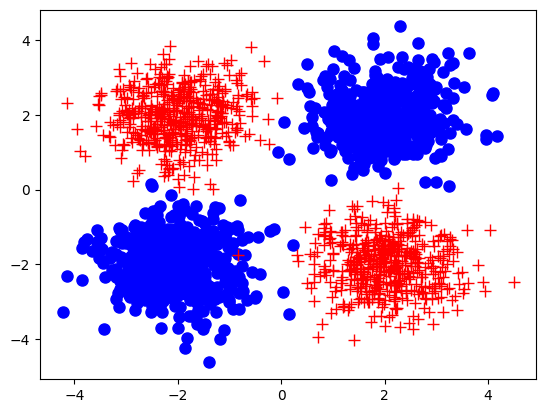

In [64]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import cholesky
from sklearn.linear_model import LogisticRegression

np.random.seed(12)

def gaussSample(mu, sigma, n):
    A = cholesky(sigma)
    Z = np.random.normal(loc=0, scale=1, size=(len(mu), n))
    return np.dot(A, Z).T + mu

def sqDistance(p, q):
    pSOS = np.sum(p ** 2, axis=1)
    qSOS = np.sum(q ** 2, axis=1)
    pSOS = np.repeat(pSOS[..., np.newaxis], len(qSOS), axis=1)
    dist = pSOS + qSOS - 2 * np.dot(p, q.T)
    return dist

def kernelRbfSigma(X1, X2, sigma):
    Z = 1.0 / np.sqrt(2 * np.pi * sigma ** 2)
    S = sqDistance(X1, X2)
    K = Z * np.exp(-1 / (2 * sigma ** 2) * S)
    return K

def createXORdata(doplot=False, N=500):
    off1 = gaussSample([-2, -2], 0.5 * np.eye(2), N)
    off2 = gaussSample([2, 2], 0.5 * np.eye(2), N)
    on1 = gaussSample([-2, 2], 0.5 * np.eye(2), N)
    on2 = gaussSample([2, -2], 0.5 * np.eye(2), N)
    X = np.concatenate([off1, off2, on1, on2], axis=0)
    y = np.concatenate([np.zeros((len(off1) + len(off2))), np.ones((len(on1) + len(on2)))], axis=0)

    if doplot:
        plt.plot(X[y == 0, 0], X[y == 0, 1], 'ob', markersize=8)
        plt.plot(X[y == 1, 0], X[y == 1, 1], '+r', markersize=8)
        plt.show()
    return X, y

X, y = createXORdata(True)

We now use LogisticRegression to solve this classification task.

Text(0.5, 1.0, 'Simple Logistic regression')

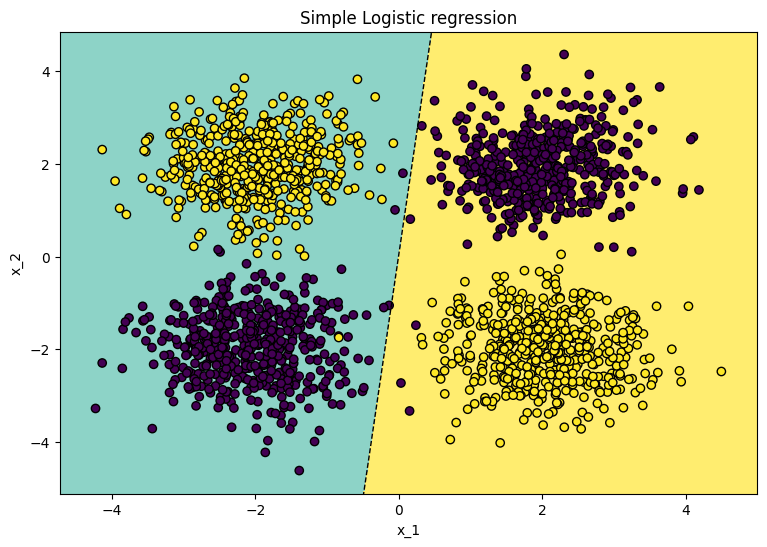

In [65]:
tol = 1e-2

model = LogisticRegression(tol=tol)
model.fit(X, y)
ypred = model.predict(X)
errorRate = np.mean(ypred != y)

clf = LogisticRegression()
clf.fit(X, y)

fig, ax1 = plt.subplots(1, 1, figsize=(9, 6))
# Retrieve the model parameters.
b = clf.intercept_[0]
w1, w2 = clf.coef_.T
# Calculate the intercept and gradient of the decision boundary.
c = -b / w2
m = -w1 / w2

x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
xd = np.array([x_min, x_max])
yd = m * xd + c
ax1.plot(xd, yd, 'k', lw=1, ls='--')
h = .02  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_plot_raw = np.c_[xx.ravel(), yy.ravel()]

Z = clf.predict(X_plot_raw)

# Put the result into a color plot
Z = Z.reshape(xx.shape)

# plot the decision boundary
ax1.pcolormesh(xx, yy, Z, cmap='Set3')

# Plot also the training points
ax1.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
ax1.set_xlim(xx.min(), xx.max())
ax1.set_ylim(yy.min(), yy.max())
ax1.set_ylabel(r'x_2')
ax1.set_xlabel(r'x_1')
ax1.set_title('Simple Logistic regression')

Your task is to implement the MLP defined in the lecture using Pytorch to solve this classification task.  

Epoch 1000, Loss: 0.6887
Epoch 2000, Loss: 0.6333
Epoch 3000, Loss: 0.5815
Epoch 4000, Loss: 0.5519
Epoch 5000, Loss: 0.5376
Epoch 6000, Loss: 0.5303
Epoch 7000, Loss: 0.5261
Epoch 8000, Loss: 0.5234
Epoch 9000, Loss: 0.5215
Epoch 10000, Loss: 0.5201
Error rate: 0.3085


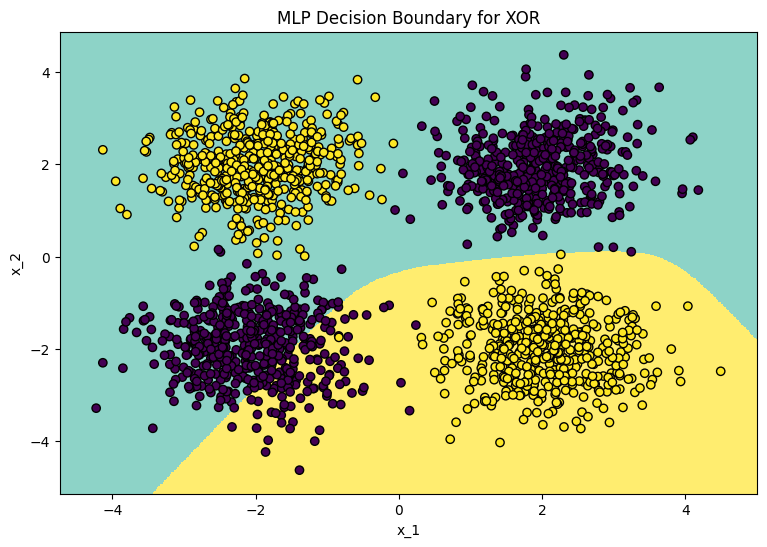

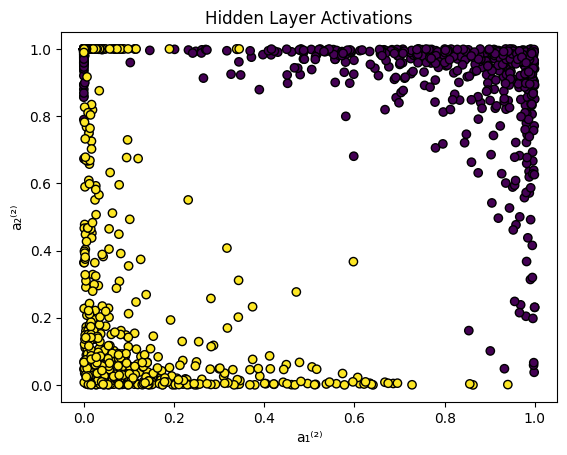

In [72]:
# remove the following line and put your codes here
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt


class MLP(nn.Module):
  def __init__(self, input_size=2, hidden_size=2, output_size=2):
    super(MLP, self).__init__()
    self.layer1 = nn.Linear(input_size, hidden_size)
    self.activation = nn.Sigmoid()
    self.layer2 = nn.Linear(hidden_size, output_size)
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = self.layer1(x)
    x = self.activation(x)
    x = self.layer2(x)
    x = self.softmax(x)
    return x

x_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y)

model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

epochs = 10000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(x_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch + 1}, Loss: {loss.item():.4f}')

with torch.no_grad():
    y_pred = model(x_tensor).argmax(dim=1).numpy()
error_rate = np.mean(y_pred != y)
print(f'Error rate: {error_rate:.4f}')

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.02
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
X_plot = np.c_[xx.ravel(), yy.ravel()]
X_plot_tensor = torch.FloatTensor(X_plot)

with torch.no_grad():
    Z = model(X_plot_tensor).argmax(dim=1).numpy().reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.pcolormesh(xx, yy, Z, cmap='Set3')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
plt.xlabel('x_1')
plt.ylabel('x_2')
plt.title('MLP Decision Boundary for XOR')
plt.show()

with torch.no_grad():
  hidden_activations = model.activation(model.layer1(x_tensor)).numpy()
plt.scatter(hidden_activations[:, 0], hidden_activations[:, 1], c=y, edgecolors='k')
plt.xlabel('a₁⁽²⁾')
plt.ylabel('a₂⁽²⁾')
plt.title('Hidden Layer Activations')
plt.show()

Train your MLPs. You'll need to plot the scatter plot of $(a_1^{(2)}, a_2^{(2)})$, and the decision boundary. Discuss how the distribution of $(a_1^{(1)}, a_1^{(2)})$ would be different that of $(x_1, x_2)$.  

Epoch [1000/10000], Loss: 0.513192
Epoch [2000/10000], Loss: 0.506539
Epoch [3000/10000], Loss: 0.505125
Epoch [4000/10000], Loss: 0.504537
Epoch [5000/10000], Loss: 0.504220
Epoch [6000/10000], Loss: 0.504022
Epoch [7000/10000], Loss: 0.503888
Epoch [8000/10000], Loss: 0.503791
Epoch [9000/10000], Loss: 0.503717
Epoch [10000/10000], Loss: 0.503660
Predictions: [0 0 1 1]
Actual values: [0. 1. 1. 0.]
Accuracy: 50.00%


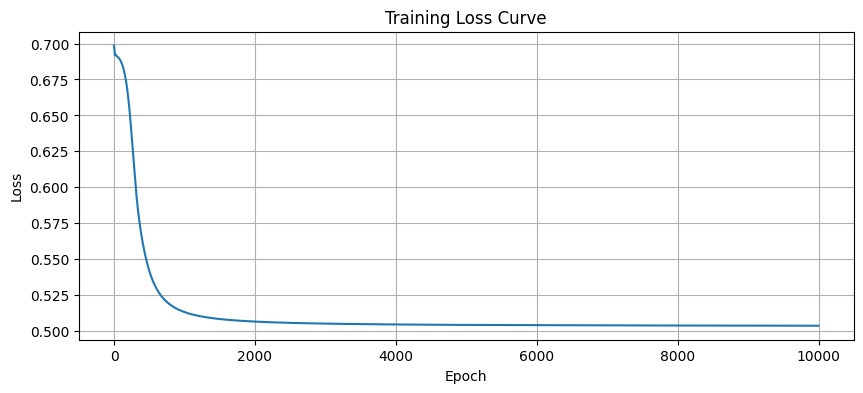

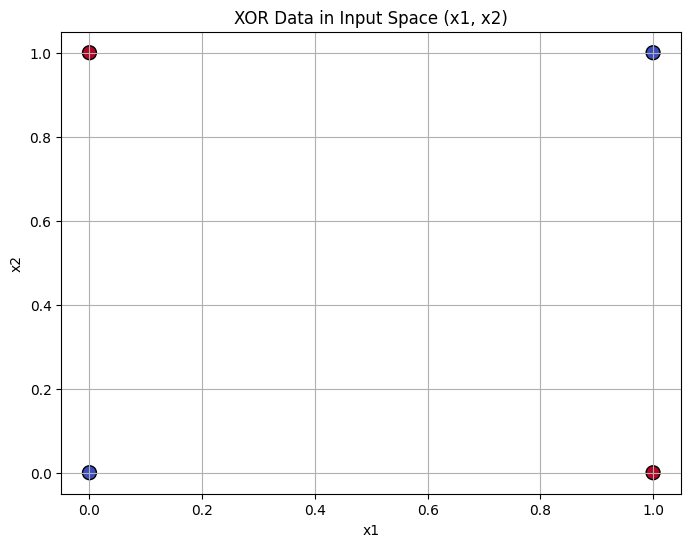

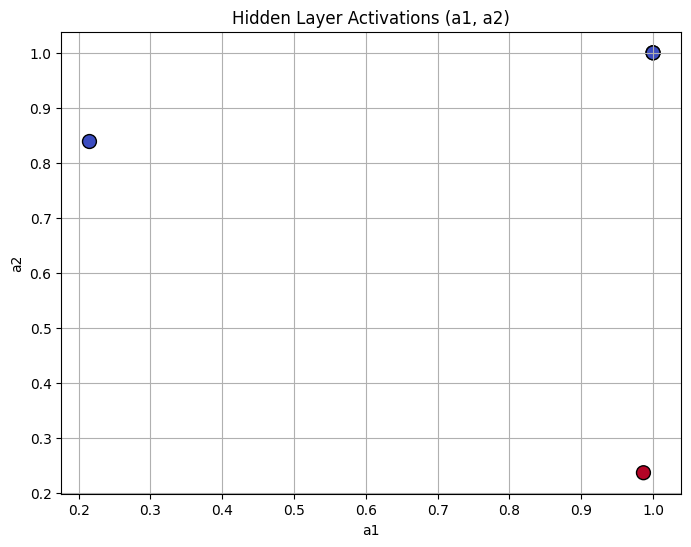

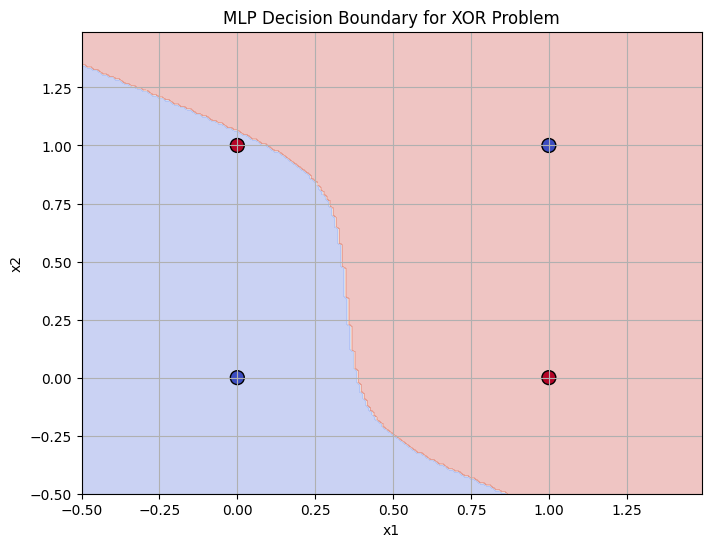

In [74]:
# put your answers here
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Prepare XOR data
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# Convert to PyTorch tensors
X_tensor = torch.from_numpy(X)
y_tensor = torch.from_numpy(y).view(-1).long()

# 2. Define MLP model
class MLP(nn.Module):
    def __init__(self, input_size=2, hidden_size=2, output_size=2):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.activation = nn.Sigmoid()
        self.layer2 = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)
        self.hidden_output = None

    def forward(self, x):
        x = self.layer1(x)
        x = self.activation(x)
        self.hidden_output = x.detach().numpy()
        x = self.layer2(x)
        x = self.softmax(x)
        return x

# 3. Initialize components
model = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

# 4. Train the model
epochs = 10000
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')

# 5. Test the model
with torch.no_grad():
    outputs = model(X_tensor)
    predicted = torch.argmax(outputs, dim=1)
    print(f'Predictions: {predicted.numpy()}')
    print(f'Actual values: {y.flatten()}')

    accuracy = (predicted.numpy() == y.flatten()).mean()
    print(f'Accuracy: {accuracy * 100:.2f}%')

# 6. Plot loss curve
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# 7. Plot input space data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100, edgecolors='k')
plt.title('XOR Data in Input Space (x1, x2)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

# 8. Plot hidden layer activations
hidden_activations = model.hidden_output
plt.figure(figsize=(8, 6))
plt.scatter(hidden_activations[:, 0], hidden_activations[:, 1], c=y, cmap='coolwarm', s=100, edgecolors='k')
plt.title('Hidden Layer Activations (a1, a2)')
plt.xlabel('a1')
plt.ylabel('a2')
plt.grid(True)
plt.show()

# 9. Plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
h = 0.01
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.from_numpy(grid_points.astype(np.float32))

with torch.no_grad():
    outputs = model(grid_tensor)
    predictions = torch.argmax(outputs, dim=1)
    Z = predictions.numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100, edgecolors='k')
plt.title('MLP Decision Boundary for XOR Problem')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.show()

(x1,x2)Distribution

*   Linearity of Separation: 	Linearly inseparable (e.g., XOR problem has no single straight line to separate classes).
*   Spatial Structure: 	Input points lie in quadrants (e.g., (0,0), (1,1) vs (0,1), (1,0) for XOR).
*   Role of Transformation: Raw input features with no nonlinear mapping.

(a₁⁽²⁾,a₂⁽²⁾)Distribution

*   Separability: Linearly separable, as the MLP's hidden layer transforms the input into a space where classes can be separated by a linear boundary.
*   Structure: Hidden layer activations reorganize these points into clusters that lie on opposite sides of a linear boundary, enabling classification.